In [14]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import cartopy.crs as ccrs


In [15]:
from OceanDataStore import OceanDataCatalog

In [16]:
catalog = OceanDataCatalog(catalog_name="noc-model-stac")

In [17]:
catalog.available_collections

['noc-rapid-evolution', 'noc-npd-jra55', 'noc-npd-era5']

In [18]:
catalog.search(collection='noc-npd-era5', standard_name='sea_surface_temperature')


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1y
              Title: eORCA1 ERA5v1 NPD T1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1m
              Title: eORCA1 ERA5v1 NPD T1m Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics monthly mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d
              Title: eORCA025 ERA5v1 NPD T1y_3d Icechunk repository
              Description: Icechunk repository containing eORCA025 ERA5v1 

In [7]:
catalog.available_items

['noc-npd-era5/npd-eorca1-era5v1/gn/T1y',
 'noc-npd-era5/npd-eorca1-era5v1/gn/T1m',
 'noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d',
 'noc-npd-era5/npd-eorca025-era5v1/gn/T1m_3d',
 'noc-npd-era5/npd-eorca025-era5v1/gn/T5d_3d',
 'noc-npd-era5/npd-eorca12-era5v1/gn/T1y_3d',
 'noc-npd-era5/npd-eorca12-era5v1/gn/T1m_3d']

In [8]:
catalog.Items[0]

<Item id=noc-npd-era5/npd-eorca1-era5v1/gn/T1y>

In [10]:
ds1 = catalog.open_dataset(id=catalog.Items[1].id,
                          start_datetime='1976-01',
                          end_datetime='1990-12',                        
                          bbox = (-85.0, 0.0, 0.0, 80.0))
ds1

<xarray.Dataset> Size: 14GB
Dimensions:                (time_counter: 180, y: 135, x: 85, deptht: 75,
                            axis_nbounds: 2)
Coordinates:
  * deptht                 (deptht) float32 300B 0.5058 1.556 ... 5.902e+03
    nav_lon                (y, x) float64 92kB -84.5 -83.5 -82.5 ... 45.74 46.87
    nav_lat                (y, x) float64 92kB 0.0 0.0 0.0 ... 80.05 79.65 79.25
    time_centered          (time_counter) datetime64[ns] 1kB dask.array<chunksize=(1,), meta=np.ndarray>
  * time_counter           (time_counter) datetime64[ns] 1kB 1976-01-16T12:00...
Dimensions without coordinates: y, x, axis_nbounds
Data variables: (12/73)
    berg_latent_heat_flux  (time_counter, y, x) float32 8MB dask.array<chunksize=(1, 135, 85), meta=np.ndarray>
    e3t                    (time_counter, deptht, y, x) float32 620MB dask.array<chunksize=(1, 25, 135, 85), meta=np.ndarray>
    empmr                  (time_counter, y, x) float32 8MB dask.array<chunksize=(1, 135, 85), meta=np.ndarray>
    evs                    (time_counter, y, x) float32 8MB dask.array<chunksize=(1, 135, 85), meta=np.ndarray>
    ficeberg               (time_counter, y, x) float32 8MB dask.array<chunksize=(1, 135, 85), meta=np.ndarray>
    friver                 (time_counter, y, x) float32 8MB dask.array<chunksize=(1, 135, 85), meta=np.ndarray>
    ...                     ...
    ttrd_atf_li            (time_counter, deptht, y, x) float32 620MB dask.array<chunksize=(1, 25, 135, 85), meta=np.ndarray>
    ttrd_bbl_li            (time_counter, deptht, y, x) float32 620MB dask.array<chunksize=(1, 25, 135, 85), meta=np.ndarray>
    vohfcisf               (time_counter, deptht, y, x) float32 620MB dask.array<chunksize=(1, 25, 135, 85), meta=np.ndarray>
    vowflisf               (time_counter, deptht, y, x) float32 620MB dask.array<chunksize=(1, 25, 135, 85), meta=np.ndarray>
    zossq                  (time_counter, y, x) float32 8MB dask.array<chunksize=(1, 135, 85), meta=np.ndarray>
    zos                    (time_counter, y, x) float32 8MB dask.array<chunksize=(1, 135, 85), meta=np.ndarray>

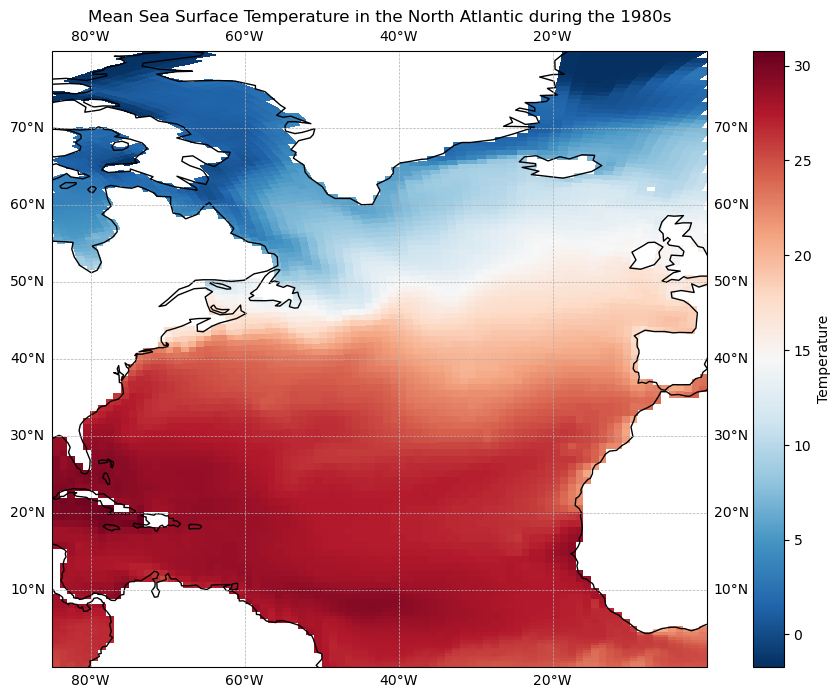

In [13]:
## Plotting North Atlantic using cartopy 

fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
data = ds1['tos_con'].sel(time_counter='1976-09', method='nearest')

# Plot using pcolormesh with explicit coordinates
im = ax.pcolormesh(ds1['nav_lon'],  ds1['nav_lat'], data, cmap='RdBu_r', transform=ccrs.PlateCarree())

#Only include the range of the colour map 
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())

# Add map features
ax.coastlines()
ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')

# Add colorbar
plt.colorbar(im, ax=ax, label='Temperature')

plt.title('Mean Sea Surface Temperature in the North Atlantic during the 1980s')
plt.show()